### Basic Info

### Background and Motivation

### Project Objectives

### Data Description

### Data Acquisition

In [58]:
import pandas as pd
import re
import matplotlib.pyplot as plt

expendituresDataFrame = pd.read_csv("independentExpenditures2024.csv")
expendituresDataFrame.head()
#Olivia - Find a data set of the current senate (so we can determine if there is a correlation between winning an election and amount spent by PACs) w/ gender

,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,cand_pty_aff,exp_amo,...,pur,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt
0,H4CO08034,"Evans, Gabe",C00866517,Go America PAC,G,CO,8.0,H,REPUBLICAN PARTY,9000.00,...,texts supporting Gabe Evans CO-8,TTHM.com,1845617,N,E2D2833410CAA40CB9A5,202410319719900778,31-OCT-24,2024,NaN,30-OCT-24
1,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,50000.00,...,Advertising Services,Northwind Strategies,1820306,N,SE.4111,202410049684791551,04-OCT-24,2024,NaN,02-OCT-24
2,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,15000.00,...,Estimated costs of consultant work,1000 Women Strong PAC,1820306,N,SE.4109,202410049684791550,04-OCT-24,2024,NaN,02-OCT-24
3,P80000722,"Harris, Kamal D",C00877886,1000 Women Strong PAC,G,NaN,0.0,P,DEMOCRATIC PARTY,7000.00,...,Production Costs for Ads,Corsair Communications,1820306,N,SE.4110,202410049684791550,04-OCT-24,2024,NaN,02-OCT-24
4,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,DEMOCRATIC PARTY,864.15,...,Direct Mail Production and Distribution (Estim...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN


### Ethical Considerations

### Data Cleaning and Processing

In [59]:
# LIV - FILTER FOR ONLY SENATE CANDIDATES

# office_groups = expendituresDataFrame.groupby("can_office")
# print(office_groups.groups.keys())
# The values of can_office are H, P, or S where H = House, P = President, and S = Senate

# mask to filter for only senate candidates:
senate_mask = expendituresDataFrame["can_office"] == "S"

# applying mask to main dataframe since we are limiting our scope to only senate candidates
expendituresDataFrame = expendituresDataFrame[senate_mask].reset_index()
expendituresDataFrame.head()
#One random donation is 6,000,000,000. I dont think that is intended so we dropped it
expendituresDataFrame = expendituresDataFrame[expendituresDataFrame['spe_nam'] != 'Republican Emo Girl'].reset_index()


In [60]:
#LIV - CAND_PTY_AFF_SIMPL CATEGORY
# adding a cand_pty_aff_simpl category, where 'D' = democrat, 'R' = republican, and 'O' = all other notations from cand_party_aff column, including na





simplified_parties = []

for row in range(len(expendituresDataFrame)):
    candidate_party = expendituresDataFrame.loc[row]["cand_pty_aff"]
    if candidate_party == "DEMOCRATIC PARTY":
        simplified_parties.append("D")
    elif candidate_party == "REPUBLICAN PARTY":
        simplified_parties.append("R")
    else:
        simplified_parties.append("O")


expendituresDataFrame["cand_pty_aff_simpl"] = simplified_parties


expendituresDataFrame.head()



,level_0,index,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,...,pay,file_num,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt,cand_pty_aff_simpl
0,0,4,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,...,Pendulum Creative Group,1845172,N,510110468,202410309719846853,30-OCT-24,2024,NaN,NaN,D
1,1,5,S4MD00327,"Alsobrooks, Angela",C90022559,1199 SEIU New York State Political Action Fund,G,MD,0.0,S,...,DT Event Consulting,1847462,N,508110469,202411039719921574,03-NOV-24,2024,NaN,NaN,D
2,2,6,S6PA00217,"Casey, Bob",C90022559,1199 SEIU New York State Political Action Fund,G,PA,0.0,S,...,Pendulum Creative Group,1845172,N,590110460,202410309719846856,30-OCT-24,2024,NaN,NaN,D
3,3,101,S4MD00327,"ALSOBROOKS, ANGELA",C00348540,1199 SEIU United Healthcare Workers East Feder...,G,MD,0.0,S,...,Karen Miller Consulting LLC,1832009,N,500117274,202410189698743719,18-OCT-24,2024,NaN,17-OCT-24,D
4,4,118,S4MT00183,"SHEEHY, TIM",C00881482,1889 PAC,G,MT,0.0,S,...,Pathfinder Communications,1794189,N,SE.4113,202407079652573607,07-JUL-24,2024,NaN,05-JUL-24,R


In [61]:
# LIV - CREATE MASK FOR REPUBLICAN AND DEMOCRAT
# republican_mask = if republican True
# democrat_mask = if democrat True
# no_other_mask = republican and democrat candidates only (omit "other" candidates)
republican_mask = expendituresDataFrame["cand_pty_aff_simpl"] == "R"
democrat_mask = expendituresDataFrame["cand_pty_aff_simpl"] == "D"
no_other_mask = expendituresDataFrame["cand_pty_aff_simpl"] != "O"

# # testing republican_mask
# expendituresDataFrame[republican_mask].head(10)
# print("republican_mask")
# print("Expecting 6301, got " + str(len(expendituresDataFrame[republican_mask])))

# # testing democrat_mask
# expendituresDataFrame[democrat_mask].head(10)
# print("democrat_mask")
# print("Expecting 9418, got " + str(len(expendituresDataFrame[democrat_mask])))

# # testing no_other_mask
# expendituresDataFrame[no_other_mask].head(10)
# print("no_other_mask")
# print("Expecting 15719, got " + str(len(expendituresDataFrame[no_other_mask])))

In [62]:
# Sam - Standardize names with IDs, throw away entries that dont match anything else. Can use district, id, and name to filter.
def clean_candidate_name(name):
    if pd.isna(name):
        return None

    name = name.upper().strip()
    # remove punctuation
    name = re.sub(r"[.,]", "", name)
    # normalize spaces
    name = re.sub(r"\s+", " ", name)
    words = name.split()
    remove_words = {"JR", "SR", "II", "III", "IV", "V", "I", "JUSTICE", "DR", "HON", "MR", "MRS", "MS"}
    words = [word for word in words if len(word) > 1 and word not in remove_words]
    return " ".join(words)

# add a cleaned name column to the end
expendituresDataFrame["cand_name_clean"]=expendituresDataFrame["cand_name"].apply(clean_candidate_name)

print("Before:", expendituresDataFrame["cand_name"].nunique())
print("After:", expendituresDataFrame["cand_name_clean"].nunique())
# find number of unique canidates IDs to compare to number of unique names
unique_candidate_ids = expendituresDataFrame["cand_id"].dropna().unique()
print(len(unique_candidate_ids))

# Sam - make sure exp-amo is numeric
expendituresDataFrame["exp_amo"] = pd.to_numeric(expendituresDataFrame["exp_amo"], errors="coerce")

Before: 215
After: 143
129


In [63]:
#Liv - Drop all donations that are not to a republican or democrat


#Liv - Create a new column titled "cand_pty_aff_bool" where a republican would be True and a democrat would be false. (could also add support for multiple parties

# Liv - create dataset for current senate members

# Liv - add boolean gender markers for current senate members; true = male false = female


In [64]:
#Sam - Create a new column for supporting/opposing converted to true/false (let supporting = true opposing = false)
expendituresDataFrame["is_support"] = expendituresDataFrame["sup_opp"] == "S"

largeDonationCutoff = 1000000 #1,000,000
#Sam - Create a new data frame with just donations > largeDonationCutoff
largeDonationsDF = expendituresDataFrame[expendituresDataFrame["exp_amo"] > largeDonationCutoff]

#Sam - Create data frame for swing states (up to you how you wanna do this)
swing_states = ["AZ", "GA", "MI", "NV", "NC", "PA", "WI"]
# Non-swing states 2024
republican_states = ["AL", "AK", "AR", "FL", "ID", "IN", "IA", "KS", "KY", "LA", "MS", "MO", "MT", "NE", "ND", "OH", "OK", "SC", "SD", "TN", "TX", "UT", "WV", "WY"]
democratic_states = ["CA", "CO", "CT", "DE", "HI", "IL", "ME", "MD", "MA", "MN", "NH", "NJ", "NM", "NY", "OR", "RI", "VA", "VT", "WA"]


In [65]:
# !!! For anything regarding the size of the donation, use exp_amo (expenditure amount) !!!
# !!! The other variable (agg_amo) is the total amount of money that PAC has spent !!!

#Jake - Create a new data frame for true republican / true democrat expenditures. Example: A donation could be for a republican candidate but be in opposition.
# In that case, it would be a democrat donation because its opposing a republican

#Jake - Create a new data frame from this true expenditure data frame filtered by the aforementioned donation cutoff

#Feel free to add anything else we need to do


republicanExpendituresDataFrame = expendituresDataFrame[expendituresDataFrame['cand_pty_aff'] == "REPUBLICAN PARTY"] #Donations to republican candidates either supposing or opposing
democratExpendituresDataFrame = expendituresDataFrame[expendituresDataFrame['cand_pty_aff'] == "DEMOCRATIC PARTY"] #Donations to democratic candidates either supposing or opposing

largeRepublicanExpendituresDataFrame = republicanExpendituresDataFrame[republicanExpendituresDataFrame['exp_amo'] > largeDonationCutoff]
largeDemocratExpendituresDataFrame = democratExpendituresDataFrame[democratExpendituresDataFrame['exp_amo'] > largeDonationCutoff]

republicanExpendituresDataFrame.head()
democratExpendituresDataFrame.head()
largeRepublicanExpendituresDataFrame.head()
largeDemocratExpendituresDataFrame.head()


,level_0,index,cand_id,cand_name,spe_id,spe_nam,ele_type,can_office_state,can_office_dis,can_office,...,amndt_ind,tran_id,image_num,receipt_dat,fec_election_yr,prev_file_num,dissem_dt,cand_pty_aff_simpl,cand_name_clean,is_support
844,844,7026,S6OH00163,"BROWN, SHERROD",C00487363,American Crossroads,G,OH,0.0,S,...,N,SE.1,202409249684705100,24-SEP-24,2024,NaN,24-SEP-24,D,BROWN SHERROD,False
849,849,7031,S6OH00163,"BROWN, SHERROD",C00487363,American Crossroads,G,OH,0.0,S,...,N,SE.5,202409179675508116,17-SEP-24,2024,NaN,17-SEP-24,D,BROWN SHERROD,False
850,850,7032,S6OH00163,"BROWN, SHERROD",C00487363,American Crossroads,G,OH,0.0,S,...,N,SE.1,202409179675508115,17-SEP-24,2024,NaN,17-SEP-24,D,BROWN SHERROD,False
853,853,7035,S6OH00163,"BROWN, SHERROD",C00487363,American Crossroads,G,OH,0.0,S,...,N,SE.1,202410159686527142,15-OCT-24,2024,NaN,15-OCT-24,D,BROWN SHERROD,False
855,855,7037,S6OH00163,"BROWN, SHERROD",C00487363,American Crossroads,G,OH,0.0,S,...,N,SE.1,202410019684773751,01-OCT-24,2024,NaN,01-OCT-24,D,BROWN SHERROD,False


### Exploratory Analysis, Analysis Methodology, and Project Questions

#### Jake - How much money do candidates in political parties receive opposing them and supporting them? What are their largest donors?

#### Sam - Top 5 biggest investors by party

Top 5 Spenders for Democratic Candidates:
                    spe_nam       exp_amo
179  Senate Leadership Fund  1.972257e+08
15      American Crossroads  5.997458e+07
91     KEYSTONE RENEWAL PAC  4.133314e+07
210         WIN IT BACK PAC  4.021808e+07
100       MARYLAND'S FUTURE  3.120674e+07



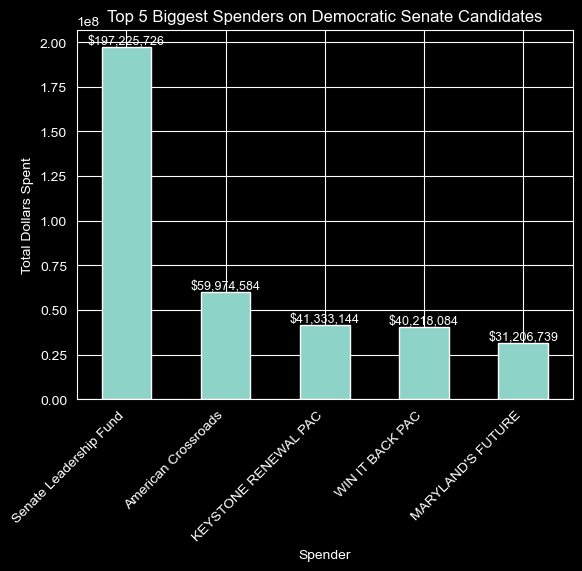

Top 5 Spenders for Republican Candidates:
                                               spe_nam       exp_amo
409                                          WinSenate  2.908055e+08
272                               DEFEND AMERICAN JOBS  5.115485e+07
246  Americans for Prosperity Action, Inc. (AFP Act...  4.828077e+07
281                                               DSCC  4.375485e+07
320                                Last Best Place PAC  3.202758e+07



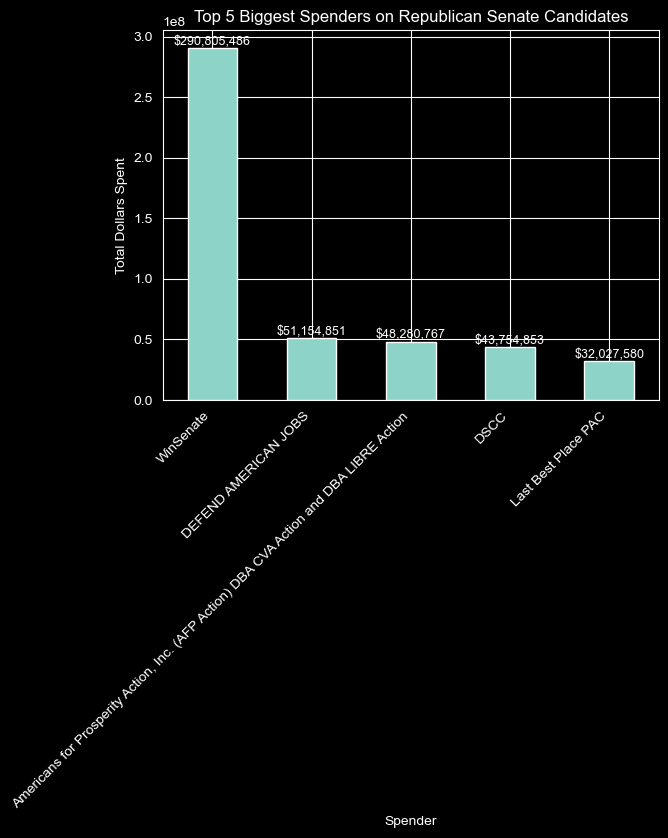

In [66]:
# just keep democratic and republican candidates
dem_rep_df = expendituresDataFrame[expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])].copy()

# group by PAC name and party
spender_totals = dem_rep_df.groupby(["cand_pty_aff", "spe_nam"])["exp_amo"].sum().reset_index()

# top 5 spenders for democrats
top5_dem = spender_totals[spender_totals["cand_pty_aff"] == "DEMOCRATIC PARTY"] \
    .sort_values("exp_amo", ascending=False) \
    .head(5)
print("Top 5 Spenders for Democratic Candidates:")
print(top5_dem[["spe_nam", "exp_amo"]])
print()
# democrat spender graph
ax = top5_dem.plot(kind="bar", x="spe_nam", y="exp_amo", legend=False)

plt.title("Top 5 Biggest Spenders on Democratic Senate Candidates")
plt.xlabel("Spender")
plt.ylabel("Total Dollars Spent")
plt.xticks(rotation=45, ha="right")
# total spending labels above bars
for i, value in enumerate(top5_dem["exp_amo"]):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

# top 5 spenders for republicans
top5_rep = spender_totals[spender_totals["cand_pty_aff"] == "REPUBLICAN PARTY"] \
    .sort_values("exp_amo", ascending=False) \
    .head(5)

print("Top 5 Spenders for Republican Candidates:")
print(top5_rep[["spe_nam", "exp_amo"]])
print()
# republican spender graph
ax = top5_rep.plot(kind="bar", x="spe_nam", y="exp_amo", legend=False)

plt.title("Top 5 Biggest Spenders on Republican Senate Candidates")
plt.xlabel("Spender")
plt.ylabel("Total Dollars Spent")
plt.xticks(rotation=45, ha="right")
# total spending labels above bars
for i, value in enumerate(top5_rep["exp_amo"]):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.show()

#### Sam - Are support or oppose expenditures bigger?

Total Spending:
is_support
False    1.012636e+09
True     4.042900e+08
Name: exp_amo, dtype: float64



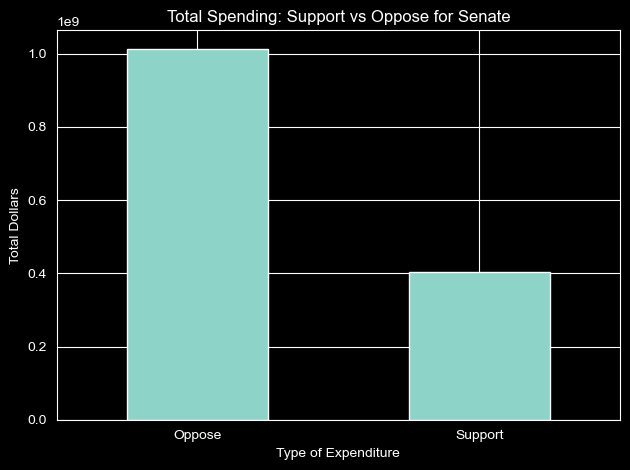

In [67]:
total_spending = expendituresDataFrame.groupby("is_support")["exp_amo"].sum()
print("Total Spending:")
print(total_spending)
print()
# total spending graph
total_spending.index = ["Oppose", "Support"]
total_spending.plot(kind="bar")
plt.title("Total Spending: Support vs Oppose for Senate")
plt.xlabel("Type of Expenditure")
plt.ylabel("Total Dollars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


#### Sam - Are support or oppose expenditures more common?

Number of Expenditures:
is_support
True     12889
False     4128
Name: count, dtype: int64



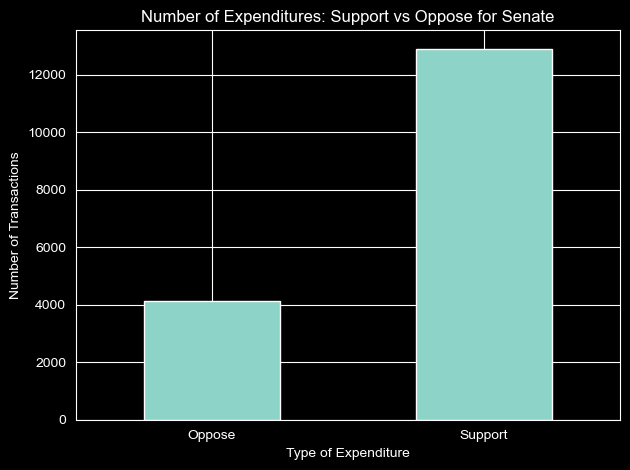

In [68]:
count_spending = expendituresDataFrame["is_support"].value_counts()

print("Number of Expenditures:")
print(count_spending)
print()
# Number of expenditures graph
count_spending = count_spending.sort_index()
count_spending.index = ["Oppose", "Support"]
count_spending.plot(kind="bar")
plt.title("Number of Expenditures: Support vs Oppose for Senate")
plt.xlabel("Type of Expenditure")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Sam - How does spending lean politically?

Spending by Party and Support/Oppose: 
cand_pty_aff             is_support
DEMOCRATIC PARTY         False         5.492033e+08
                         True          1.497258e+08
DEMOCRATIC-FARMER-LABOR  True          5.251533e+04
INDEPENDENT              False         9.001124e+06
                         True          1.327241e+07
LIBERTARIAN PARTY        True          2.706779e+05
OTHER                    True          3.465882e+04
REPUBLICAN PARTY         False         4.494045e+08
                         True          2.172260e+08
Name: exp_amo, dtype: float64



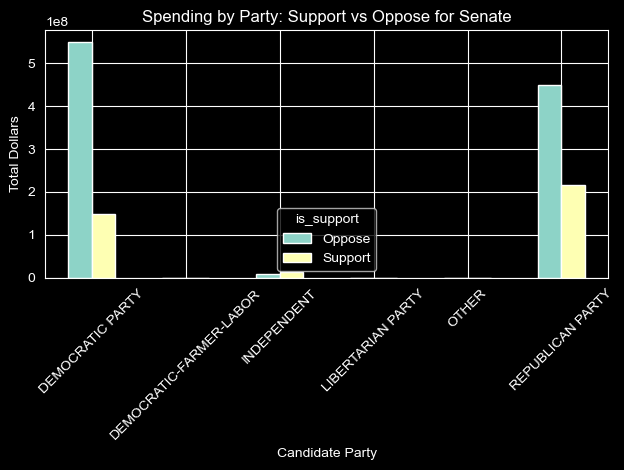

In [69]:
party_spending = expendituresDataFrame.groupby(["cand_pty_aff", "is_support"])["exp_amo"].sum()

print("Spending by Party and Support/Oppose: ")
print(party_spending)
print()
# Spending by party graph
party_spending.unstack().rename(columns={False: "Oppose", True: "Support"}).plot(kind="bar")
plt.title("Spending by Party: Support vs Oppose for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Total Dollars")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Sam - Are Democrats or Republicans getting more support or opposition?

Democratic vs Republican Spending (Support/Oppose):
is_support               False         True 
cand_pty_aff                                
DEMOCRATIC PARTY  5.492033e+08  1.497258e+08
REPUBLICAN PARTY  4.494045e+08  2.172260e+08



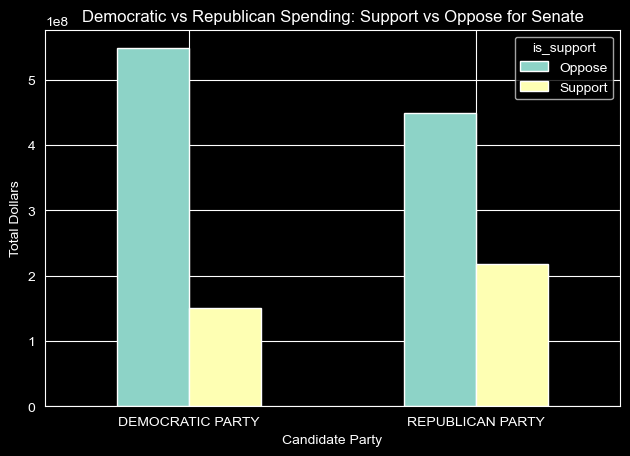

In [70]:
# Are Democrats or Republicans getting more support or opposition?
dem_rep_df = expendituresDataFrame[expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])]
dem_rep_support_opp = dem_rep_df.groupby(["cand_pty_aff", "is_support"])["exp_amo"].sum().unstack(fill_value=0)

print("Democratic vs Republican Spending (Support/Oppose):")
print(dem_rep_support_opp)
print()
# Are democrats to republicans supporting or opposing more graph
dem_rep_support_opp = dem_rep_support_opp.rename(columns={False: "Oppose", True: "Support"})
dem_rep_support_opp.plot(kind="bar")
plt.title("Democratic vs Republican Spending: Support vs Oppose for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Total Dollars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Sam - Republican and Democratic Spending Subtracting OK

Democratic vs Republican Spending (Support/Oppose):
is_support               False         True 
cand_pty_aff                                
DEMOCRATIC PARTY  5.492033e+08  1.497258e+08
REPUBLICAN PARTY  4.491545e+08  2.172260e+08



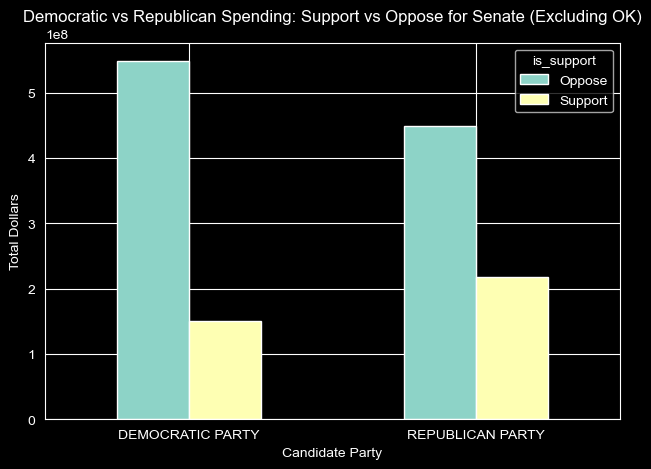

In [71]:
# Are Democrats or Republicans getting more support or opposition?
dem_rep_df = expendituresDataFrame[
    (expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])) &
    (expendituresDataFrame["can_office_state"] != "OK")
]

dem_rep_support_opp = dem_rep_df.groupby(["cand_pty_aff", "is_support"])["exp_amo"].sum().unstack(fill_value=0)

print("Democratic vs Republican Spending (Support/Oppose):")
print(dem_rep_support_opp)
print()

# Are democrats to republicans supporting or opposing more graph
dem_rep_support_opp = dem_rep_support_opp.rename(columns={False: "Oppose", True: "Support"})
dem_rep_support_opp.plot(kind="bar")

plt.title("Democratic vs Republican Spending: Support vs Oppose for Senate (Excluding OK)")
plt.xlabel("Candidate Party")
plt.ylabel("Total Dollars")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Sam - Net spending on parties

Democrat vs Republican Support/Oppose Spending:
is_support              Oppose       Support  Net Spending
cand_pty_aff                                              
DEMOCRATIC PARTY  5.492033e+08  1.497258e+08 -3.994775e+08
REPUBLICAN PARTY  4.494045e+08  2.172260e+08 -2.321785e+08



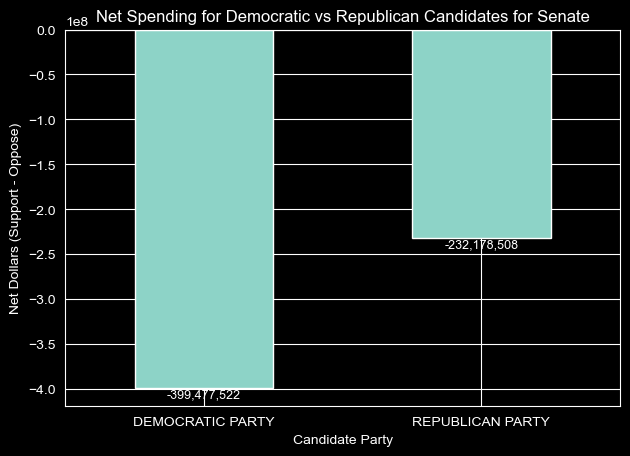

In [72]:
# net spending = support - oppose
dem_rep_df = expendituresDataFrame[expendituresDataFrame["cand_pty_aff"].isin(["DEMOCRATIC PARTY", "REPUBLICAN PARTY"])].copy()
# group support and oppose spending
dem_rep_support_opp = dem_rep_df.groupby(["cand_pty_aff", "is_support"])["exp_amo"].sum().unstack(fill_value=0)
# rename columns to look better
dem_rep_support_opp = dem_rep_support_opp.rename(columns={False: "Oppose", True: "Support"})
# net spending
dem_rep_support_opp["Net Spending"] = dem_rep_support_opp["Support"] - dem_rep_support_opp["Oppose"]

print("Democrat vs Republican Support/Oppose Spending:")
print(dem_rep_support_opp)
print()
# net spending graph
ax = dem_rep_support_opp["Net Spending"].plot(kind="bar")
plt.title("Net Spending for Democratic vs Republican Candidates for Senate")
plt.xlabel("Candidate Party")
plt.ylabel("Net Dollars (Support - Oppose)")
plt.xticks(rotation=0)
plt.axhline(0)
# net spending labels
for i, value in enumerate(dem_rep_support_opp["Net Spending"]):
    if value >= 0:
        ax.text(i, value, f"{value:,.0f}", ha="center", va="bottom", fontsize=9)
    else:
        ax.text(i, value, f"{value:,.0f}", ha="center", va="top", fontsize=9)

plt.tight_layout()
plt.show()

#### What are the biggest Super PACs donating? Where do they primarily donate and generally how do they lean politically?

In [73]:
#This is where you can use agg_amo

#### Jake - Which political parties receive larger single donations, or donations from a single group?  Which receives smaller donations? Which receives a higher quantity of donations?

#### Jake - Does the size of a donation correlate with Republican or Democrat?

In [74]:
# Im not sure how to visualize this but maybe a scatter plot colored by part affiliation?

#### Olivia - What effect do these donations have on the current Senate?

#### Sam - How do swing states differ than non swing states

Total spending by state:
   state  total_spending state_group
32    OH    3.141112e+08  Republican
34    PA    2.437889e+08       Swing
22    MT    1.702232e+08  Republican
18    MI    1.456032e+08       Swing
42    WI    1.240836e+08       Swing
30    NV    1.062022e+08       Swing
2     AZ    8.064944e+07       Swing
38    TX    6.076690e+07  Republican
16    MD    5.675728e+07  Democratic
26    NE    3.129331e+07  Republican
3     CA    2.499922e+07  Democratic
39    UT    1.685594e+07  Republican
7     FL    1.106355e+07  Republican
43    WV    8.088527e+06  Republican
20    MO    4.456665e+06  Republican
12    IN    4.218781e+06  Republican
29    NM    4.075653e+06  Democratic
15    MA    2.111275e+06  Democratic
28    NJ    1.899095e+06  Democratic
37    TN    1.163468e+06  Republican
44    WY    1.007628e+06  Republican
40    VA    6.884924e+05  Democratic
8     GA    5.988017e+05       Swing
21    MS    4.700500e+05  Republican
35    RI    3.485373e+05  Democratic
33    OK    2

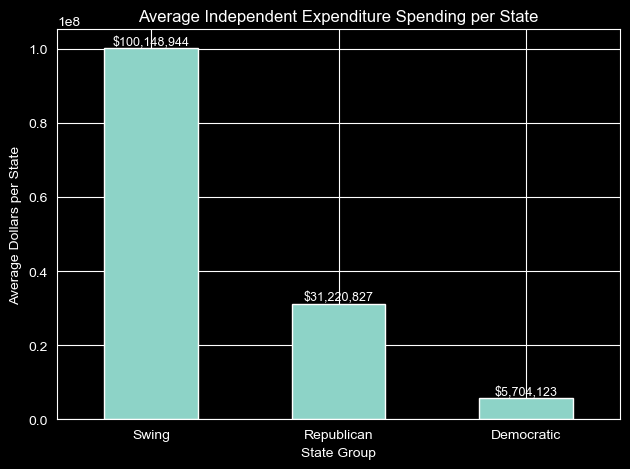

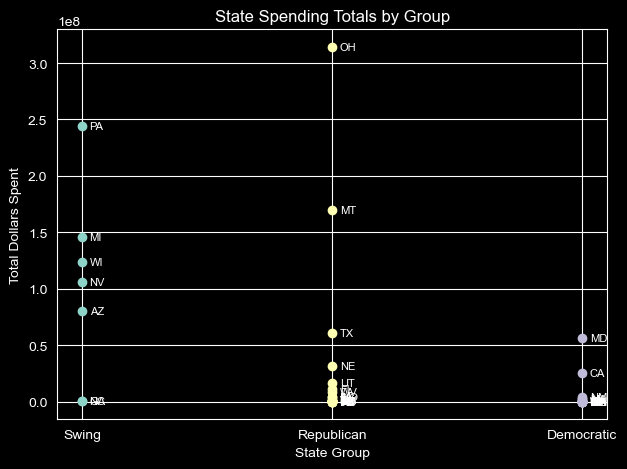

In [75]:
# total spending by state
state_totals = expendituresDataFrame.groupby("can_office_state")["exp_amo"].sum().reset_index()
state_totals.columns = ["state", "total_spending"]

# classify state into republican, democrat, or swing
def classify_state(state):
    if state in swing_states:
        return "Swing"
    elif state in republican_states:
        return "Republican"
    elif state in democratic_states:
        return "Democratic"
    else:
        return "Other"
state_totals["state_group"] = state_totals["state"].apply(classify_state)


print("Total spending by state:")
print(state_totals.sort_values("total_spending", ascending=False))
print()

# average spending per state for each group
group_avg = state_totals.groupby("state_group")["total_spending"].mean().reindex(["Swing", "Republican", "Democratic"])

print("Average spending per state by group:")
print(group_avg)
print()

# total spending and number of states in each group
group_summary = state_totals.groupby("state_group").agg(average_spending=("total_spending", "mean"),total_spending=("total_spending", "sum"),number_of_states=("state", "count")).reindex(["Swing", "Republican", "Democratic"])

print("Summary by group:")
print(group_summary)
print()

# Average spending per state bar graph
ax = group_avg.plot(kind="bar")
plt.title("Average Independent Expenditure Spending per State")
plt.xlabel("State Group")
plt.ylabel("Average Dollars per State")
plt.xticks(rotation=0)
for i, value in enumerate(group_avg):
    ax.text(i, value, f"${value:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

# Individual state totals dot graph
# driven by only a few states
group_order = ["Swing", "Republican", "Democratic"]
x_positions = {group: i for i, group in enumerate(group_order)}

for group in group_order:
    group_data = state_totals[state_totals["state_group"] == group]
    x_vals = [x_positions[group]] * len(group_data)
    plt.scatter(x_vals, group_data["total_spending"])

    # label each point with the state abbreviation
    for _, row in group_data.iterrows():
        plt.text( x_positions[group] + 0.03, row["total_spending"], row["state"], fontsize=8, va="center")

plt.xticks([0, 1, 2], group_order)
plt.title("State Spending Totals by Group")
plt.xlabel("State Group")
plt.ylabel("Total Dollars Spent")
plt.tight_layout()
plt.show()

#### Jake - Where do donations differ?

In [19]:
print("The number of Republican SUPER PACs expenditures from 2022-24 is " + str(republicanExpendituresDataFrame.size))
print("The number of Democrat SUPER PACs expenditures from 2022-24 is " + str(democratExpendituresDataFrame.size))

print("The number of large Republican SUPER PACs expenditures (>$1,000,000) from 2022-24 is " + str(largeRepublicanExpendituresDataFrame.size))
print("The number of large Democrat SUPER PACs expenditures (>$1,000,000) from 2022-24 is " + str(largeDemocratExpendituresDataFrame.size))


totalRepublicanExpenditures = republicanExpendituresDataFrame['exp_amo'].sum()
totalDemocratExpenditures = democratExpendituresDataFrame['exp_amo'].sum()

totalLargeRepublicanExpenditures = largeRepublicanExpendituresDataFrame['exp_amo'].sum()
totalLargeDemocratExpenditures = largeDemocratExpendituresDataFrame['exp_amo'].sum()


print(f"The sum of all large republican expenditures was {totalLargeRepublicanExpenditures}")
print(f"The sum of all large democrat expenditures was {totalLargeDemocratExpenditures}")
#Still need to do more, ex how much of the large donations make up the total donation amount?


The number of Republican SUPER PACs expenditures from 2022-24 is 170127
The number of Democrat SUPER PACs expenditures from 2022-24 is 254286
The number of large Republican SUPER PACs expenditures (>$1,000,000) from 2022-24 is 4725
The number of large Democrat SUPER PACs expenditures (>$1,000,000) from 2022-24 is 5049
The sum of all large republican expenditures was 6732732651.150001
The sum of all large democrat expenditures was 441851678.11


### Peer Feedback
Group you paired with, names of those present
Effects of Air Quality on National Park Visitor Statistics: Dylan Bradley-Wilson, Abby Marye, Taylor Durrant
Names of your team members present
Olivia Wright, Jake Scott, Sam Lewis
Major points of feedback received from other team (+ how/ if you plan to address)
Narrow scope down, create categories for different groups of objectives/ questions, create an absolute amount spent rather than spending and opposing, weigh candidates against each other (gender), affect the number of each party running on data related to parties. Create a PCA
Comment on the quality of feedback your team received (e.g., helpful, fair)
Very thoughtful and helpful. They were attentive and pointed out some things to work on for our project.


### List of Completed Milestones & Method Milestones

### Summary